In [42]:
import pandas as pd
from os import scandir
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import pickle
import maincode.cvTools as cst
import maincode.extractor as ex

# Results
Otsu and H thresholding seems the best choice, even though there still is room to improve

# Thresholding - HSV

### bad example

In [43]:
low = (0, 110, 50)
high = (23, 255, 210)
thresh = {}
low, high, thresh = cst.threshing('data/NV/ISIC_0000039_downsampled.jpg', 'HSV', thresh=thresh, low=low, high=high)

### Good example

In [44]:
low = (0, 110, 50)
high = (23, 255, 210)
thresh = {}
low, high, thresh = cst.threshing('data/NV/ISIC_0008236_downsampled.jpg', 'HSV', thresh=thresh, low=low, high=high)


# Thresholding - LAB

In [48]:
low, high = cst.threshing('data/MEL/ISIC_0014366_downsampled.jpg', 'LAB')


# Thresholding - Gray

In [49]:
img_path = 'data/MEL/ISIC_0014366_downsampled.jpg'
low = 0
high = 0

img = cv.imread(img_path)
win_name = img_path[5:-4]
cv.namedWindow('Original - ' + win_name, cv.WINDOW_NORMAL)
cv.namedWindow((touch := 'Masked - ' + win_name), cv.WINDOW_NORMAL)
M = 255
cv.createTrackbar('Value - Low', touch, 0, M, cst.still)
cv.createTrackbar('Value - High', touch, 0, M, cst.still)
if low is not None: cv.setTrackbarPos('Value - Low', touch, low)
if high is not None: cv.setTrackbarPos('Value - High', touch, high)

while True:
    low = cv.getTrackbarPos('Value - Low', touch)
    high = cv.getTrackbarPos('Value - High', touch)
    res = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    mask = cv.inRange(res, low, high)
    res = cv.bitwise_and(res, res, mask=mask)
    res = cv.cvtColor(res, cv.COLOR_GRAY2BGR)
    cv.imshow('Original - ' + win_name, img)
    cv.imshow(touch, res)
    if cv.waitKey(20) & 0xFF == 27: break
cv.destroyAllWindows()

# Thresholding - Otsu

In [50]:
img_path = 'data/MEL/ISIC_0062181.jpg'
img = cv.imread(img_path)

## median filter to remove hair & artifacts
temp = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
# for _ in range(5): temp = cv.medianBlur(temp, 5)
_, lens = cv.threshold(temp, 10, 255, cv.THRESH_BINARY) # throw away borders
rows = [cv.hasNonZero(lens[i]) for i in range(lens.shape[0])]
cols = [cv.hasNonZero(lens[:,i]) for i in range(lens.shape[1])]
# mean = cv.mean(temp, lens)
# temp = cv.add(temp, mean, temp, mask=cv.bitwise_not(lens))[rows][:, cols]
temp = cv.add(temp, cv.bitwise_not(lens))[rows][:, cols]
cst.show([temp])
temp = cv.dilate(temp, np.ones((5,5), dtype=np.uint8),iterations=1)

## otsu
_, otsu = cv.threshold(temp, 0, 255, cv.THRESH_BINARY_INV+cv.THRESH_OTSU)
# _, threshf = cv.threshold(temp, 0, 255, cv.THRESH_BINARY_INV+cv.THRESH_OTSU)

## h thresholding
# temp2 = cv.cvtColor(img[rows][:, cols], cv.COLOR_BGR2HSV)
# _, thresh1 = cv.threshold(temp2[..., 0], 23, 255, cv.THRESH_BINARY_INV)
# _, thresh2 = cv.threshold(temp2[..., 0], 160, 255, cv.THRESH_BINARY)
# threshH = cv.bitwise_or(thresh1, thresh2)

# put them together
# threshf = cv.bitwise_and(threshH, otsu)
# trim zero rows and columns
# rows2 = [cv.hasNonZero(threshf[i]) for i in range(threshf.shape[0])]
# cols2 = [cv.hasNonZero(threshf[:,i]) for i in range(threshf.shape[1])]
rows2 = [cv.hasNonZero(otsu[i]) for i in range(otsu.shape[0])]
cols2 = [cv.hasNonZero(otsu[:,i]) for i in range(otsu.shape[1])]
res = cv.bitwise_and(img[rows][:, cols], img[rows][:, cols], mask=otsu)[rows2][:, cols2]
cst.show([img, temp, otsu, res], ['img', 'filter', 'otsu', 'res'])

# Watershed

In [21]:
img_path = 'data/MEL/ISIC_0000035_downsampled.jpg'
img = cv.imread(img_path)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
ret, thresh = cv.threshold(gray,0,255,cv.THRESH_BINARY_INV+cv.THRESH_OTSU)
# cst.show([thresh])
kernel = np.ones((3,3),np.uint8)
opening = cv.morphologyEx(thresh,cv.MORPH_OPEN,kernel, iterations = 2)
 
# sure background area
sure_bg = cv.dilate(opening,kernel,iterations=3)
 
# Finding sure foreground area
dist_transform = cv.distanceTransform(opening,cv.DIST_L2,5)
ret, sure_fg = cv.threshold(dist_transform,0.7*dist_transform.max(),255,0)
 
# Finding unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv.subtract(sure_bg, sure_fg)
# cst.show([sure_fg, unknown], ['sure', 'not sure'])
ret, markers = cv.connectedComponents(sure_fg)
# plt.imshow(markers)
# plt.show()
 
# Add one to all labels so that sure background is not 0, but 1
markers = markers+1
markers[:201, :] = 0 
markers[-200:, :] = 0 
markers[:, :201] = 0
markers[:, -200:] = 0
# Now, mark the region of unknown with zero
markers[unknown==255] = 0
pre = np.copy(markers)
markers = cv.watershed(img,markers)
img[markers == -1] = [0,0,255]

# KMeans

In [56]:
img = cv.imread('data/NV/ISIC_0007796_downsampled.jpg')
# show(img)
Z = img.reshape((-1, 3)).astype(np.float32)
img = cv.cvtColor(cv.imread('data/NV/ISIC_0007796_downsampled.jpg'), cv.COLOR_BGR2HSV)
prova = cv.inRange(img, (0, 100, 16), (17, 255, 200))

# define criteria, number of clusters(K) and apply kmeans()
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 2
_, label, center = cv.kmeans(Z,K,None,criteria,10, cv.KMEANS_PP_CENTERS)
 
# Now convert back into uint8, and make original image
center = np.uint8(center)

# darker region
arg_dark = np.argmin(center[..., 0])
flat_idx = np.nonzero(label.flatten() == arg_dark)

# mask for image
mask = np.zeros(img.shape[0] * img.shape[1], dtype=np.uint8)
mask[flat_idx] = 255
mask = mask.reshape(img.shape[:2])

masked_img = cv.bitwise_and(img, img, mask=mask)

# bilateral filter
bil = cv.bilateralFilter(masked_img, d=9, sigmaColor=10, sigmaSpace=39)
# masked_img = cv.cvtColor(masked_img, cv.COLOR_BGR2GRAY)
masked_img = cv.cvtColor(masked_img, cv.COLOR_BGR2LAB)
bil = cv.cvtColor(bil, cv.COLOR_BGR2LAB)
# create a CLAHE object (Arguments are optional).
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl1 = clahe.apply(masked_img[..., 0])
cl2 = clahe.apply(bil[..., 0])
bil[..., 0] = cl2
masked_img[..., 0] = cl1

# out = np.hstack((masked_img, cl1))
# show(out)
cst.show([cv.cvtColor(masked_img, cv.COLOR_LAB2BGR)])
cst.show([cv.cvtColor(bil, cv.COLOR_LAB2BGR)])

# Matplotlib hsv

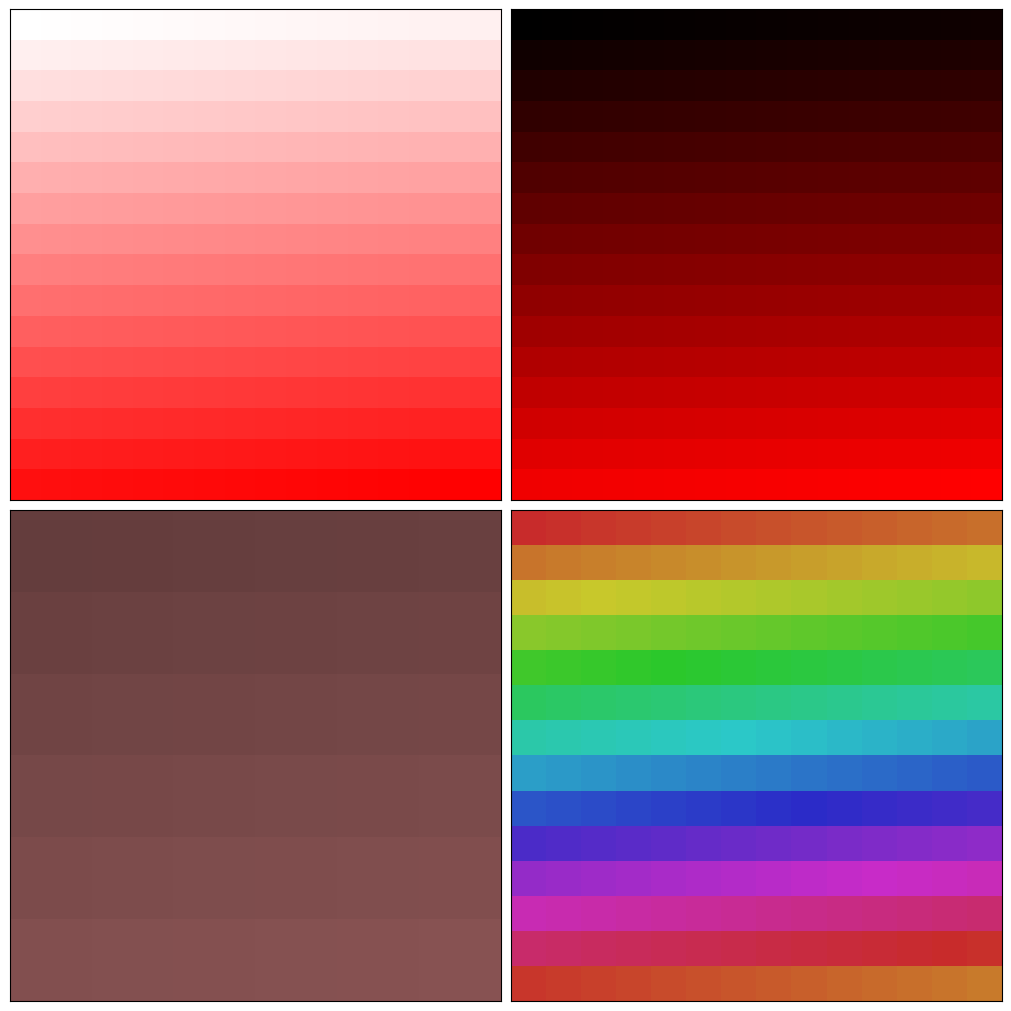

In [66]:
h = 180
img_sat = np.empty((16, 16, 3), dtype=np.uint8)
img_sat[..., 0] = h
img_sat[..., 1] = np.arange(256).reshape(16, 16)
img_sat[..., 2] = 255
img_sat = cv.cvtColor(img_sat, cv.COLOR_HSV2RGB)

img_val = np.empty((16, 16, 3), dtype=np.uint8)
img_val[..., 0] = h
img_val[..., 1] = 255
img_val[..., 2] = np.arange(256).reshape(16, 16)
img_val = cv.cvtColor(img_val, cv.COLOR_HSV2RGB)

cus = 100
img_cus = np.empty((6, 6, 3), dtype=np.uint8)
img_cus[..., 0] = h
img_cus[..., 1] = cus
img_cus[..., 2] = np.arange(cus, cus + 36).reshape(6, 6)
# img_cus[..., 2] = np.arange(cus, cus + 36).reshape(6, 6)
img_cus = cv.cvtColor(img_cus, cv.COLOR_HSV2RGB)

img_h = np.empty((14, 14, 3), dtype=np.uint8)
img_h[..., 0] = np.arange(196).reshape(14, 14)
img_h[..., 1] = 200
img_h[..., 2] = 200
img_h = cv.cvtColor(img_h, cv.COLOR_HSV2RGB)
# img_h = np.empty((1, 179-160, 3), dtype=np.uint8)
# img_h[..., 0] = np.arange(160, 179)
# img_h[..., 1] = 255
# img_h[..., 2] = 255
# img_h = cv.cvtColor(img_h, cv.COLOR_HSV2RGB)


fig, ax = plt.subplots(2,2, figsize=(10, 10), layout='constrained')
ax = ax.ravel()
for i, img in enumerate((img_sat, img_val, img_cus, img_h)):
    ax[i].imshow(img)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.show()

# Final vs Watershed

In [34]:
## custom
# img_path = 'data/NV/ISIC_0000256.jpg'

# img_path = 'data/NV/ISIC_0000217.jpg'
img_path = 'data/NV/ISIC_0000229.jpg'
# img_path = 'data/MEL/ISIC_0070061.jpg'
clahe = cv.createCLAHE(clipLimit=1, tileGridSize=(10,10))
sift = cv.SIFT_create()

img = cv.imread(img_path)[1:-1, 1:-1, :]  # some photos have white borders
lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)

### trimming hair
lab = cv.dilate(lab, np.ones((3,3), dtype=np.uint8), iterations=2)
lab = cv.erode(lab, np.ones((3,3), dtype=np.uint8), iterations=2)
# cst.show([img, cv.cvtColor(lab, cv.COLOR_LAB2BGR)], ['original', 'new'])

### CLAHE
change = cv.cvtColor(lab, cv.COLOR_LAB2BGR) 
lab[..., 0] = clahe.apply(lab[..., 0])
cst.show([img, change, cv.cvtColor(lab, cv.COLOR_LAB2BGR)], ['original', 'old', 'new'])


## h thresholding
otsu, lab = ex.thresholder(lab)

### kill small patches
conts, contSave = ex.counter(otsu, 1000)
if len(contSave) == 0: conts, contSave = ex.counter(otsu, 100)
if len(contSave) != 0:
    otsu = np.zeros_like(otsu)
    for cont in contSave: cv.drawContours(otsu, conts, cont, 255, -1)
    rows = [cv.hasNonZero(otsu[i]) for i in range(otsu.shape[0])]
    cols = [cv.hasNonZero(otsu[:,i]) for i in range(otsu.shape[1])]
    lab = (lab[rows][:, cols]).copy()
    otsu = (otsu[rows][:, cols]).copy()
lab = cv.bitwise_and(lab, lab, mask=otsu)

### Filtering
outcst = cv.bilateralFilter(lab, d=30, sigmaColor=20, sigmaSpace=10)
cst.show([cv.cvtColor(outcst, cv.COLOR_LAB2BGR)])

In [38]:
## watershed
lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)

### trimming hair
kernel = np.ones((3, 3), dtype=np.uint8)
lab = cv.morphologyEx(lab,cv.MORPH_CLOSE,kernel, iterations = 2)

### CLAHE
lab[..., 0] = clahe.apply(lab[..., 0])


## h thresholding
otsu, lab = ex.thresholder(lab)

# sure background area
opening = cv.morphologyEx(otsu,cv.MORPH_OPEN,kernel, iterations = 2)
sure_bg = cv.dilate(opening,kernel,iterations=3)
 
# Finding sure foreground area
dist_transform = cv.distanceTransform(opening,cv.DIST_L2,5)
ret, sure_fg = cv.threshold(dist_transform,0.7*dist_transform.max(),255,0)
 
# Finding unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv.subtract(sure_bg, sure_fg)
# cst.show([sure_fg, unknown], ['sure', 'not sure'])
ret, markers = cv.connectedComponents(sure_fg)
# plt.imshow(markers)
# plt.show()
 
# Add one to all labels so that sure background is not 0, but 1
markers = markers+1
markers[:201, :] = 0 
markers[-200:, :] = 0 
markers[:, :201] = 0
markers[:, -200:] = 0
# Now, mark the region of unknown with zero
markers[unknown==255] = 0
pre = np.copy(markers)
out = cv.cvtColor(lab, cv.COLOR_LAB2BGR)
markers = cv.watershed(out,markers)
out[markers == -1] = [0,0,255]

In [39]:
cst.show([img, cv.cvtColor(outcst, cv.COLOR_LAB2BGR), out], ['original', 'custom', 'water'])

In [32]:
lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
    
    ### trimming hair
lab = cv.morphologyEx(lab, cv.MORPH_CLOSE, np.ones((3,3), dtype=np.uint8), iterations=2)
bgr = cv.cvtColor(lab, cv.COLOR_LAB2BGR)
temp = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
_, thresh = cv.threshold(temp[..., 0], 23, 255, cv.THRESH_BINARY_INV)
_, thresh2 = cv.threshold(temp[..., 0], 110, 255, cv.THRESH_BINARY)
thresh = cv.bitwise_or(thresh, thresh2)

## lensing
temp = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
lens = np.zeros_like(temp)
cv.thresholdWithMask(temp, lens, thresh, 10, 255, cv.THRESH_BINARY)  # lens is the new mask of active pxs
rows = [cv.hasNonZero(lens[i]) for i in range(lens.shape[0])]
cols = [cv.hasNonZero(lens[:, i]) for i in range(lens.shape[1])]
lens = (lens[rows][:, cols])[40:-40, 40:-40].copy()
lab = (lab[rows][:, cols])[40:-40, 40:-40, :].copy()
cst.show([lens])
## otsu
otsu = np.zeros_like(lab[..., 0])
cv.thresholdWithMask(lab[..., 0], otsu, lens, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
cst.show([otsu])

# Save image for LaTeX

In [38]:
## custom
# img_path = 'data/NV/ISIC_0000319.jpg'  # example
img_path = 'data/MEL/ISIC_0055513.jpg'  # failed cropping
# img_path = 'data/MEL/ISIC_0014136_downsampled.jpg'  # blue band-aid
clahe = cv.createCLAHE(clipLimit=1, tileGridSize=(10,10))
sift = cv.SIFT_create()

img = cv.imread(img_path)[1:-1, 1:-1, :]  # some photos have white borders
lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)

### trimming hair
lab = cv.dilate(lab, np.ones((3,3), dtype=np.uint8), iterations=2)
lab = cv.erode(lab, np.ones((3,3), dtype=np.uint8), iterations=2)
# cst.show([img, cv.cvtColor(lab, cv.COLOR_LAB2BGR)], ['original', 'new'])
# cv.imwrite('report/figures/ISIC_0000319_hair_trimmed.png', cv.cvtColor(lab, cv.COLOR_LAB2BGR))

### CLAHE
# change = cv.cvtColor(lab, cv.COLOR_LAB2BGR) 
lab[..., 0] = clahe.apply(lab[..., 0])
# cst.show([img, change, cv.cvtColor(lab, cv.COLOR_LAB2BGR)], ['original', 'old', 'new'])
# cv.imwrite('report/figures/ISIC_0000319_CLAHE.png', cv.cvtColor(lab, cv.COLOR_LAB2BGR))


## h thresholding
 ## H thresh
# bgr = cv.cvtColor(lab, cv.COLOR_LAB2BGR)
# temp = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
# _, thresh = cv.threshold(temp[..., 0], 23, 255, cv.THRESH_BINARY_INV)
# _, thresh2 = cv.threshold(temp[..., 0], 110, 255, cv.THRESH_BINARY)
# thresh = cv.bitwise_or(thresh, thresh2)
# cst.show([img, thresh], ['original', 'thresh'])

## lensing
# temp = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
# lens = np.zeros_like(temp)
# cv.thresholdWithMask(temp, lens, thresh, 10, 255, cv.THRESH_BINARY)  # lens is the new mask of active pxs
# rows = [cv.hasNonZero(lens[i]) for i in range(lens.shape[0])]
# cols = [cv.hasNonZero(lens[:, i]) for i in range(lens.shape[1])]
# lens = (lens[rows][:, cols])[40:-40, 40:-40].copy()
# lab = (lab[rows][:, cols])[40:-40, 40:-40, :].copy()


# ## otsu
# otsu = np.zeros_like(lab[..., 0])
# cv.thresholdWithMask(lab[..., 0], otsu, lens, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)


otsu, lab = ex.thresholder(lab)
cst.show([otsu])
# cv.imwrite('report/figures/ISIC_0000319_thresh.png', otsu)


## kill small patches
# conts, _ = cv.findContours(otsu, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)
# cx = []
# cy = []
# for cont in conts:
#     mom = cv.moments(cont)
#     if mom['m00'] == 0: continue
#     cx.append(int(mom['m10'] / mom['m00']))
#     cy.append(int(mom['m01'] / mom['m00']))
    
# change = cv.cvtColor(otsu, cv.COLOR_GRAY2BGR)
# cv.drawContours(change, conts, -1, (200,0,0), 2)
# for x,y in zip(cx, cy): cv.circle(change, (x,y), 1, (0,0,240), 2)
# cst.show([change])
# cv.imwrite('report/figures/ISIC_0000319_contours.png', change)


conts, contSave = ex.counter(otsu, 1000)
if len(contSave) == 0: conts, contSave = ex.counter(otsu, 100)
if len(contSave) != 0:
    otsu = np.zeros_like(otsu)
    for cont in contSave: cv.drawContours(otsu, conts, cont, 255, -1)
    rows = [cv.hasNonZero(otsu[i]) for i in range(otsu.shape[0])]
    cols = [cv.hasNonZero(otsu[:,i]) for i in range(otsu.shape[1])]
    lab = (lab[rows][:, cols]).copy()
    otsu = (otsu[rows][:, cols]).copy()
# cst.show([otsu])
# cv.imwrite('report/figures/ISIC_0000319_final_mask.png', otsu)

lab = cv.bitwise_and(lab, lab, mask=otsu)

### Filtering
lab = cv.bilateralFilter(lab, d=30, sigmaColor=20, sigmaSpace=10)
outcst = cv.cvtColor(lab, cv.COLOR_LAB2BGR)
outcst[np.all(outcst == [194, 64, 0], axis=-1)] = 0
cst.show([img, outcst], ['original', 'out'])
# cv.imwrite('report/figures/ISIC_0014136_downsampled_hue.png', outcst)


# kp = sift.detect(lab[..., 0], otsu)
# cv.drawKeypoints(outcst, kp, outcst, (0,0,255), cv.DRAW_MATCHES_FLAGS_DRAW_OVER_OUTIMG)
# cv.imwrite('report/figures/ISIC_0000319_SIFT.png', outcst)